In [90]:
using Plots,JLD2,LinearAlgebra

In [91]:
Nx=10
Ny=10
tper=0.37

tpa=2.0
tNNN=0.16

α=-1.2

β=-1.2
K=1.0;
KNNN=1.0;

filling=1.25
#trytime=1

1.25

In [92]:
st=load("10Nx10Ny0.37tper2.0tpa0.16tNNN-1.2alpha-1.2beta1.0K1.0KNNN1.25filling1try1seed.jld2")
   

Dict{String, Any} with 14 entries:
  "Echemical"           => -4.34155
  "relevant_qset"       => [[3, 3, 1], [3, 3, 2], [3, 7, 1], [3, 7, 2]]
  "relevant_qamplitude" => ComplexF64[0.389857+0.729282im, -0.389857-0.729282im…
  "Eelec"               => -2.4619
  "spectrum"            => [-4.74, -4.74, -4.61618, -4.61618, -4.61577, -4.6157…
  "max_record"          => 0.328165
  "average_record"      => 0.224347
  "orbital_id"          => [1 11 … 81 91; 2 12 … 82 92; … ; 9 19 … 89 99; 10 20…
  "phonon_id"           => [1 11 … 81 91; 2 12 … 82 92; … ; 9 19 … 89 99; 10 20…
  "phonon_coor"         => [-0.113405, 0.280286, -0.0598209, -0.243315, 0.21019…
  "FL"                  => 1.56101
  "ave_npa"             => 125.0
  "E_total"             => -2.39029
  "Egap"                => 0.175017

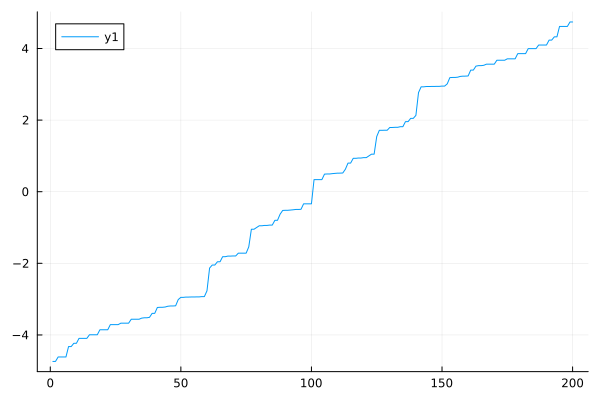

In [93]:
plot(st["spectrum"])

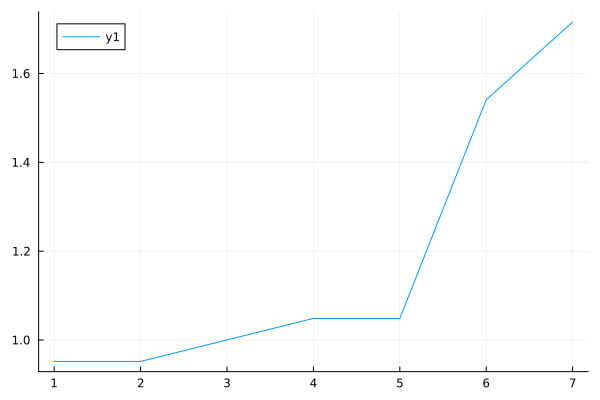

In [94]:
plot(st["spectrum"][120:126])

In [95]:
st=load("10Nx10Ny0.37tper2.0tpa0.16tNNN-1.2alpha-1.2beta1.0K1.0KNNN1.25filling2try1seed.jld2")

Dict{String, Any} with 14 entries:
  "Echemical"           => -4.58421
  "relevant_qset"       => [[3, 3, 1], [3, 3, 2], [3, 7, 1], [3, 7, 2]]
  "relevant_qamplitude" => ComplexF64[0.00845564-0.00263972im, 0.00845564-0.002…
  "Eelec"               => -2.38795
  "spectrum"            => [-4.74001, -4.74, -4.59868, -4.59868, -4.59868, -4.5…
  "max_record"          => 0.00239162
  "average_record"      => 0.00154789
  "orbital_id"          => [1 11 … 81 91; 2 12 … 82 92; … ; 9 19 … 89 99; 10 20…
  "phonon_id"           => [1 11 … 81 91; 2 12 … 82 92; … ; 9 19 … 89 99; 10 20…
  "phonon_coor"         => [-0.00167847, 0.00105783, 0.00102469, -0.00169113, 2…
  "FL"                  => 1.75702
  "ave_npa"             => 125.0
  "E_total"             => -2.38793
  "Egap"                => 1.33227e-15

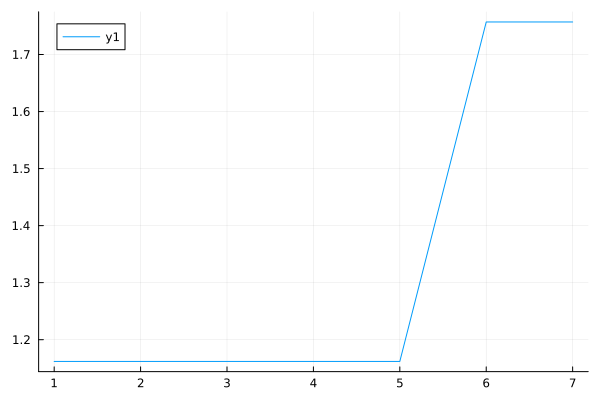

In [96]:
plot(st["spectrum"][120:126])

In [97]:
abs.(st[ "relevant_qamplitude"])

4-element Vector{Float64}:
 0.008858099550349973
 0.008858099548308478
 4.7124135978571476e-14
 4.718733209878982e-14

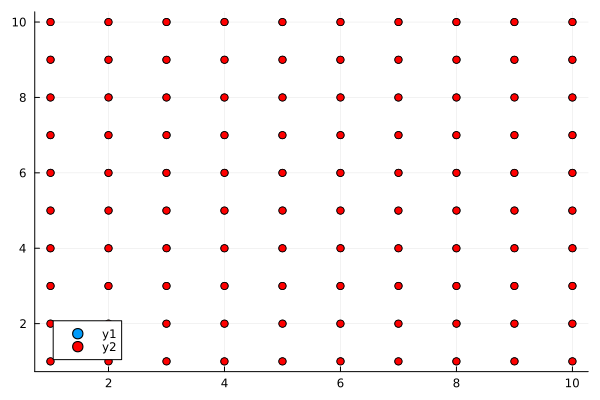

In [98]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end
#COM_x=sum(dis_x)/(Nx*Ny)
#COM_y=sum(dis_y)/(Nx*Ny)
#dis_x=dis_x .- COM_x
#dis_y=dis_y .- COM_y
#quiver(vec(atom_x),vec(atom_y),quiver=(0.5*vec(dis_x),0.5*vec(dis_y)))

scatter(vec(dis_x),vec(dis_y))
scatter!(vec(atom_x),vec(atom_y),color=:red)


In [99]:
sort(vec(dis_y)-vec(atom_y))

100-element Vector{Float64}:
 -0.0016911273644897307
 -0.0016911273644897307
 -0.0016911273644888425
 -0.0016911273644888425
 -0.0016911273644799607
 -0.0016911273644796276
 -0.0016911273644781843
 -0.0016911273644772962
 -0.0016911273644724112
 -0.001691127364471967
  ⋮
  0.0016911273644724112
  0.0016911273644772962
  0.0016911273644781843
  0.0016911273644795166
  0.0016911273644799607
  0.0016911273644888425
  0.0016911273644888425
  0.0016911273644897307
  0.0016911273644897307

In [100]:
sort(vec(sqrt.(dis_x.^2+dis_y.^2)))

100-element Vector{Float64}:
  1.4118398491184232
  2.2374872591634225
  2.237487259163503
  2.8298762582169594
  3.163573870928183
  3.1635738709283543
  3.603206134288785
  3.603206134288915
  4.121055016154924
  4.121055016155191
  ⋮
 12.043964196710302
 12.208893216489285
 12.208893216489393
 12.726426059842202
 12.804761624357974
 12.804761624357996
 13.45217691676831
 13.452176916768355
 14.144527238985768

In [101]:
sum(vec(sqrt.(dis_x.^2+dis_y.^2)))/(Nx*Ny)

8.29981020350237

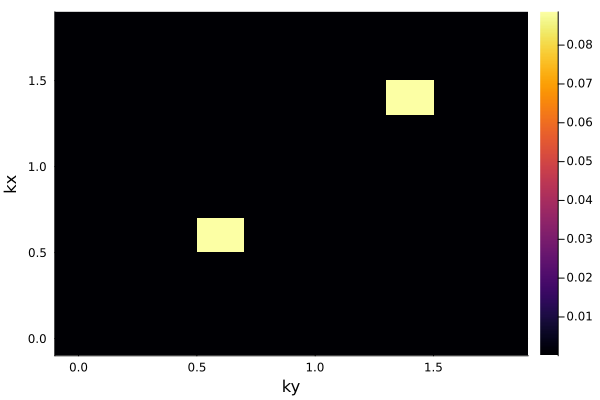

In [102]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode[ja,jb]+=phonon_coor[phonon_id[jc,jd,2]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode),xlabel="ky",ylabel="kx")

In [103]:
abs.(Fourier_mode)

10×10 Matrix{Float64}:
 4.11997e-18  1.50265e-17  8.94236e-18  …  1.12281e-17  1.50129e-17
 1.52287e-17  1.36772e-17  8.94308e-18     1.48327e-17  6.8586e-18
 9.44501e-18  1.03703e-17  1.31432e-18     3.10939e-18  1.97653e-17
 3.25261e-18  6.33579e-18  5.45144e-18     1.43219e-17  5.78494e-17
 4.94591e-18  6.85525e-18  7.52274e-18     3.1012e-18   1.17353e-17
 6.50521e-19  1.1932e-17   3.60185e-17  …  1.65894e-17  5.74037e-17
 5.93149e-18  1.34815e-17  5.09249e-18     4.14352e-17  1.34648e-17
 2.82725e-18  1.97469e-17  1.61531e-17     4.61432e-17  5.43801e-17
 1.02036e-17  1.40787e-17  2.45106e-18     1.98078e-18  1.29612e-18
 1.56008e-17  5.63936e-18  2.1239e-17      2.1721e-19   5.97899e-17

In [104]:
findmax(abs.(Fourier_mode))

(0.0885809954830848, CartesianIndex(4, 4))

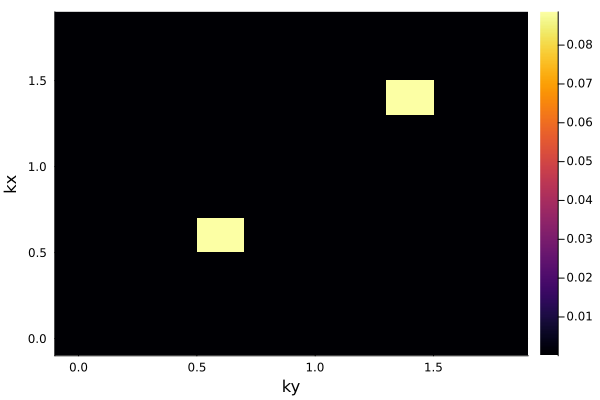

In [105]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode[ja,jb]+=phonon_coor[phonon_id[jc,jd,1]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode),xlabel="ky",ylabel="kx")

In [106]:
findmax(abs.(Fourier_mode))

(0.08858099550349971, CartesianIndex(4, 4))